In [18]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [19]:
#Load Dataset
df = pd.read_csv("CarPrice_Assignment.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [20]:
#Basic Data Exploration
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

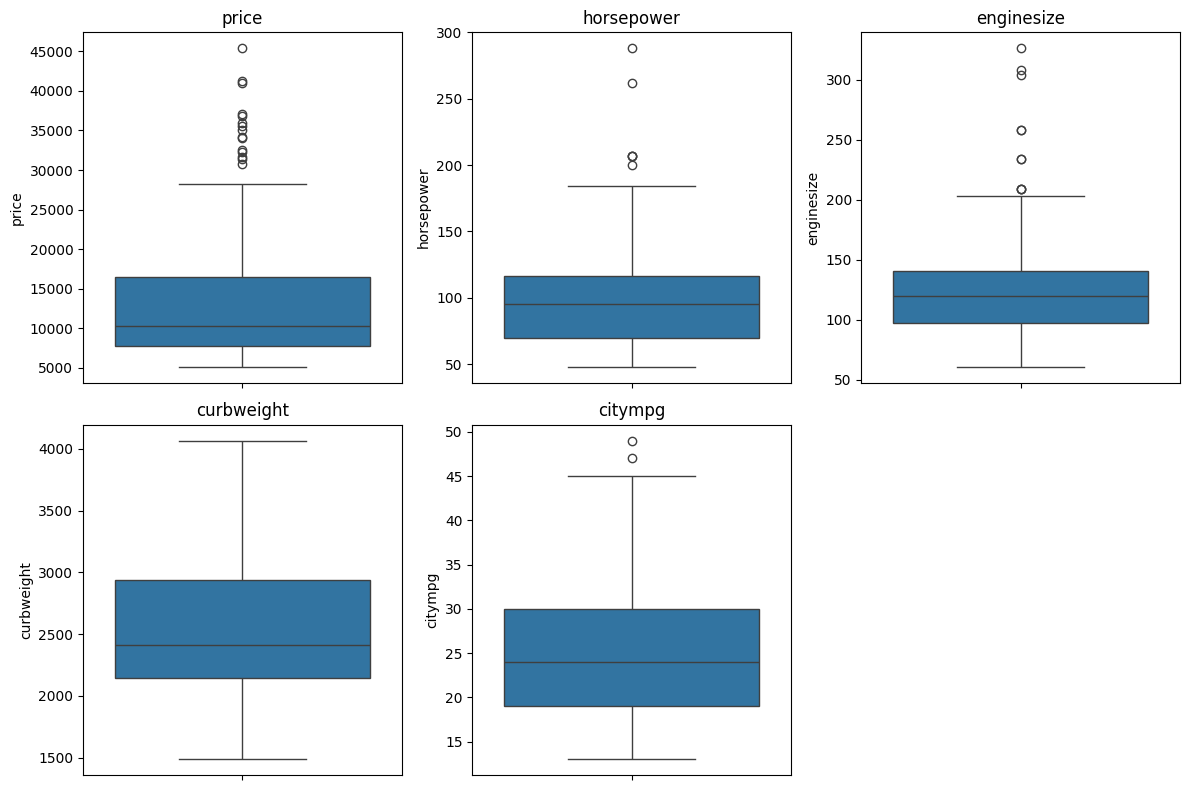

In [21]:
#Outlier Detection (Boxplot)
numeric_cols = ['price','horsepower','enginesize','curbweight','citympg']

plt.figure(figsize=(12,8))

for i,col in enumerate(numeric_cols,1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [22]:
# Outlier Handling (IQR Method)
df_clean = df.copy()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean[col] = np.where(df_clean[col] < lower, lower, df_clean[col])
    df_clean[col] = np.where(df_clean[col] > upper, upper, df_clean[col])

In [23]:
# Feature Engineering
df_clean['carCompany'] = df_clean['CarName'].apply(lambda x: x.split()[0])

In [24]:
#Encoding Categorical Data
#Label Encoding
label_cols = ['doornumber','cylindernumber']

le = LabelEncoder()

for col in label_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

In [25]:
#One Hot Encoding
categorical_cols = [
'fueltype','aspiration','carbody',
'drivewheel','enginelocation',
'enginetype','fuelsystem','carCompany'
]

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols)

In [26]:
#Define Features and Target
X = df_encoded.drop(['car_ID','CarName','price'], axis=1)
y = df_encoded['price']

In [27]:
# Feature Scaling
scaler = StandardScaler()

X_scaled = X.copy()
X_scaled[X_scaled.columns] = scaler.fit_transform(X_scaled)

In [28]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [29]:
#Simple Linear Regression
simple_lr = LinearRegression()

X_train_simple = X_train[['horsepower']]
X_test_simple = X_test[['horsepower']]

simple_lr.fit(X_train_simple, y_train)

y_pred_simple = simple_lr.predict(X_test_simple)

print("Simple Linear Regression")
print("R2:", r2_score(y_test, y_pred_simple))
print("MAE:", mean_absolute_error(y_test, y_pred_simple))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_simple)))

Simple Linear Regression
R2: 0.6662851719100424
MAE: 2987.2712105837877
RMSE: 4204.061259630305


In [30]:
#Multiple Linear Regression
multiple_lr = LinearRegression()

multiple_lr.fit(X_train, y_train)

y_pred_multi = multiple_lr.predict(X_test)

print("\nMultiple Linear Regression")
print("R2:", r2_score(y_test, y_pred_multi))
print("MAE:", mean_absolute_error(y_test, y_pred_multi))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_multi)))


Multiple Linear Regression
R2: 0.9186446443849062
MAE: 1502.8810215155104
RMSE: 2075.7467063756785


In [31]:
#Ridge Regression
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("\nRidge Regression")
print("R2:", r2_score(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))


Ridge Regression
R2: 0.9277134102172934
MAE: 1481.837149593895
RMSE: 1956.6365054560902


In [32]:
# Model Comparison
results = pd.DataFrame({

"Model":["Simple Linear","Multiple Linear","Ridge"],

"R2 Score":[
r2_score(y_test,y_pred_simple),
r2_score(y_test,y_pred_multi),
r2_score(y_test,y_pred_ridge)
]

})

print(results.sort_values(by="R2 Score",ascending=False))

             Model  R2 Score
2            Ridge  0.927713
1  Multiple Linear  0.918645
0    Simple Linear  0.666285
